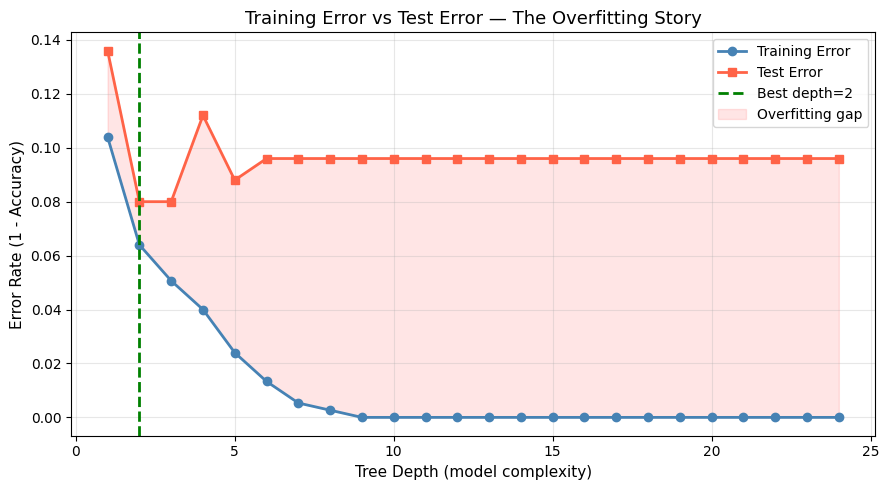

In [ ]:
# ■■ Training Error vs Test Error Gap ■■
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt, numpy as np
X, y = make_classification(n_samples=500, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)
train_errs, test_errs = [], []
depths = range(1, 25)
for d in depths:
  tree = DecisionTreeClassifier(
      max_depth=d,
      random_state=42)


  tree.fit(X_train, y_train)

  train_errs.append(1 - accuracy_score(y_train, tree.predict(X_train)))
  test_errs.append(1 - accuracy_score(y_test, tree.predict(X_test)))


best = depths[test_errs.index(min(test_errs))]


plt.figure(figsize=(9, 5))
plt.plot(depths, train_errs, 'o-', lw=2, color='steelblue', label='Training Error')
plt.plot(depths, test_errs, 's-', lw=2, color='tomato', label='Test Error')
plt.axvline(x=best, color='green', lw=2, linestyle='--', label=f'Best depth={best}')
plt.fill_between(depths, train_errs, test_errs, alpha=0.1, color='red', label='Overfitting gap')
plt.xlabel('Tree Depth (model complexity)', fontsize=11)
plt.ylabel('Error Rate (1 - Accuracy)', fontsize=11)
plt.title('Training Error vs Test Error — The Overfitting Story', fontsize=13)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# ■■ Cross-Validation: One-liner + StratifiedKFold + Pipeline ■■
from sklearn.datasets import make_classification
from sklearn.model_selection import (cross_val_score, KFold,
StratifiedKFold, cross_validate)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np



In [ ]:
X, y = make_classification(n_samples=600, n_features=10, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
# ■■ Method 1: Simplest one-liner ■■
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f'5-Fold CV Scores: {scores.round(3)}')
print(f'Mean: {scores.mean():.3f} Std: {scores.std():.3f}')
print(f'Reliable range: {scores.mean()-2*scores.std():.3f} – {scores.mean()+2*scores.std():.3f}')

5-Fold CV Scores: [0.858 0.933 0.908 0.9   0.942]
Mean: 0.908 Std: 0.029
Reliable range: 0.850 – 0.967


In [ ]:
# ■■ Method 2: StratifiedKFold (keeps class ratio in each fold) ■■
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
strat_scores = cross_val_score(model, X, y, cv=skf, scoring='f1_macro')
print(f'\nStratified 5-Fold F1: {strat_scores.mean():.3f} ± {strat_scores.std():.3f}')


Stratified 5-Fold F1: 0.908 ± 0.027


In [ ]:
# ■■ Method 3: cross_validate — get multiple metrics at once ■■
results = cross_validate(model, X, y, cv=5,
scoring=['accuracy','f1_macro','roc_auc'],
    return_train_score=True)
print('\ncross_validate results:')
for metric in ['accuracy','f1_macro','roc_auc']:
  train_k = f'train_{metric}'
  test_k = f'test_{metric}'
  print(f' {metric:12s}: train={results[train_k].mean():.3f} test={results[test_k].mean():.3f}')


cross_validate results:
 accuracy    : train=1.000 test=0.908
 f1_macro    : train=1.000 test=0.908
 roc_auc     : train=1.000 test=0.970


In [ ]:
# ■■ Method 4: Pipeline + CV (scale inside CV — no data leakage!) ■■
pipe = Pipeline([
('scaler', StandardScaler()), # Scale inside each fold
('model', LogisticRegression(max_iter=1000))
])
pipe_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
print(f'\nPipeline CV (no leakage): {pipe_scores.mean():.3f} ± {pipe_scores.std():.3f}')


Pipeline CV (no leakage): 0.915 ± 0.030


In [ ]:
# ■■ Model Comparison Leaderboard ■■
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd, numpy as np, matplotlib.pyplot as plt
X, y = make_classification(n_samples=800, n_features=15, random_state=42)

In [ ]:
# ■■ Define models (wrapped in Pipeline to include scaling) ■■
models = {
'Logistic Regression' : Pipeline([('sc',StandardScaler()),('m',LogisticRegression(max_iter=1000))]),
'Decision Tree' : DecisionTreeClassifier(max_depth=5, random_state=42),
'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
'KNN (k=5)' : Pipeline([('sc',StandardScaler()),('m',KNeighborsClassifier(n_neighbors=5))])
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    cv_res = cross_validate(model,X, y, cv=cv, scoring=['accuracy', 'f1_macro', 'roc_auc'],return_train_score=False)
    results.append({
        'Model': name,
        'Accuracy': cv_res['test_accuracy'].mean(),
        'F1 Score': cv_res['test_f1_macro'].mean(),
        'AUC-ROC': cv_res['test_roc_auc'].mean(),
        'CV Std': cv_res['test_accuracy'].std(),
    })
    print(f'{name:22s}: '
        f'Acc={results[-1]["Accuracy"]:.3f} '
        f'F1={results[-1]["F1 Score"]:.3f} '
        f'AUC={results[-1]["AUC-ROC"]:.3f} '
    )

Logistic Regression   : Acc=0.930 F1=0.930 AUC=0.975 
Decision Tree         : Acc=0.925 F1=0.925 AUC=0.948 
Random Forest         : Acc=0.936 F1=0.936 AUC=0.977 
KNN (k=5)             : Acc=0.886 F1=0.886 AUC=0.949 


In [ ]:
# ■■ Build the leaderboard ■■
df_res = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
df_res[['Accuracy','F1 Score','AUC-ROC','CV Std']] = df_res[['Accuracy','F1 Score','AUC-ROC','CV Std']].round(4)
print('\n' + '='*70)
print('MODEL LEADERBOARD')
print('='*70)
print(df_res.to_string(index=False))


MODEL LEADERBOARD
              Model  Accuracy  F1 Score  AUC-ROC  CV Std
      Random Forest    0.9362    0.9362   0.9775  0.0310
Logistic Regression    0.9300    0.9300   0.9752  0.0222
      Decision Tree    0.9250    0.9249   0.9481  0.0265
          KNN (k=5)    0.8863    0.8860   0.9487  0.0242


In [ ]:
# ■■ GridSearchCV
from sklearn.model_selection import GridSearchCV  StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
import pandas as pd, numpy as np
X, y = make_classification(n_samples=600, n_features=12, random_state=42)

In [ ]:
param_grid = {
    'max_depth': [2, 4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'criterion': ['gini', 'entropy']
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42
)
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=param_grid, cv=cv, scoring='accuracy')grid_search.fit(X, y)
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", round(grid_search.best_score_, 4))

Best Parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Accuracy: 0.9083


In [ ]:
results = pd.DataFrame(grid_search.cv_results_)

# Top 5 models
top_5 = results[
    ['param_max_depth', 'param_criterion',
     'mean_test_score', 'rank_test_score']
].sort_values('rank_test_score').head(5)

print("\nTop 5 Models:")
print(top_5)


Top 5 Models:
   param_max_depth param_criterion  mean_test_score  rank_test_score
61               4         entropy         0.908333                1
62               4         entropy         0.908333                1
60               4         entropy         0.908333                1
0                2            gini         0.903333                4
4                2            gini         0.903333                4


LAB : MODEL COMPARISION DASHBOARD

Build a complete model selection pipeline: load data, preprocess, train 4 models, evaluate with cross-validation, tune
hyperparameters, and produce a final comparison report. We use the Pima Indians Diabetes dataset as the
benchmark.

Step 1 — Load, Clean, Split

In [ ]:
# ■■ Load and Clean ■■
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time, warnings; warnings.filterwarnings('ignore')

import os
if not os.path.exists('diabetes.csv'):
    !wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

df = pd.read_csv('diabetes.csv')
for col in ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']:
  df[col] = df[col].replace(0, df[col].median())
X = df.drop('Outcome', axis=1)
y = df['Outcome']
print(f'Dataset: {X.shape[0]} rows, {X.shape[1]} features')
print(f'Class balance: {y.value_counts().to_dict()}')

--2026-06-05 01:28:22--  https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23873 (23K) [text/plain]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  23.31K  --.-KB/s    in 0s      

2026-06-05 01:28:22 (81.2 MB/s) - ‘diabetes.csv’ saved [23873/23873]

Dataset: 768 rows, 8 features
Class balance: {0: 500, 1: 268}


Step 2 — Build Models & Run Cross-Validation

In [ ]:
# ■■ Cross-Validation Leaderboard ■■
# Models — LR and KNN need scaling; trees don't (Pipeline handles this cleanly)
models = {
    'Logistic Regression': Pipeline([('sc',StandardScaler()),
('m',LogisticRegression(max_iter=1000,random_state=42))]),
'Decision Tree' : DecisionTreeClassifier(max_depth=5, random_state=42),
'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
'KNN' : Pipeline([('sc',StandardScaler()),
('m',KNeighborsClassifier(n_neighbors=7))]),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = ['accuracy','f1_macro','roc_auc','precision_macro','recall_macro']
records = []
for name, model in models.items():
  t0 = time.time()
  res = cross_validate(model, X, y, cv=cv, scoring=metrics)
  elapsed = time.time()-t0
  row = {'Model': name, 'Time(s)': round(elapsed,2)}
  for m in metrics:
    row[m.replace('_macro','').title()] = round(res[f'test_{m}'].mean(), 4)
    row[f'{m.replace('_macro','').title()}_std'] = round(res[f'test_{m}'].std(), 4)
  records.append(row)
leaderboard = pd.DataFrame(records).sort_values('Accuracy', ascending=False)
print(leaderboard[['Model','Accuracy','F1','Roc_Auc','Precision','Recall','Time(s)']].to_string(index=False))

              Model  Accuracy     F1  Roc_Auc  Precision  Recall  Time(s)
Logistic Regression    0.7708 0.7320   0.8372     0.7602  0.7219     0.19
      Random Forest    0.7577 0.7236   0.8235     0.7367  0.7170     2.78
                KNN    0.7435 0.7026   0.7912     0.7206  0.6948     0.14
      Decision Tree    0.7082 0.6682   0.7516     0.6851  0.6719     0.12


Step 3 — Tune the Best Model with GridSearchCV

In [ ]:
# ■■ GridSearch Tuning ■■
param_grid = {
    'n_estimators' : [50, 100, 200],
'max_depth' : [None, 5, 10],
'min_samples_leaf': [1, 3, 5],
}
gs = GridSearchCV(RandomForestClassifier(random_state=42),param_grid, cv=cv, scoring='accuracy',n_jobs=-1, verbose=0)
gs.fit(X, y)
print(f'Best params : {gs.best_params_}')
print(f'Best CV acc : {gs.best_score_:.4f}')

default_rf = RandomForestClassifier(n_estimators=100, random_state=42)
default_scores = cross_val_score(default_rf, X, y, cv=cv, scoring='accuracy')
tuned_scores = cross_val_score(gs.best_estimator_, X, y, cv=cv, scoring='accuracy')
print(f'\nDefault RF accuracy: {default_scores.mean():.4f} ± {default_scores.std():.4f}')
print(f'Tuned RF accuracy: {tuned_scores.mean():.4f} ± {tuned_scores.std():.4f}')

Best params : {'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 50}
Best CV acc : 0.7759

Default RF accuracy: 0.7577 ± 0.0266
Tuned RF accuracy: 0.7759 ± 0.0367


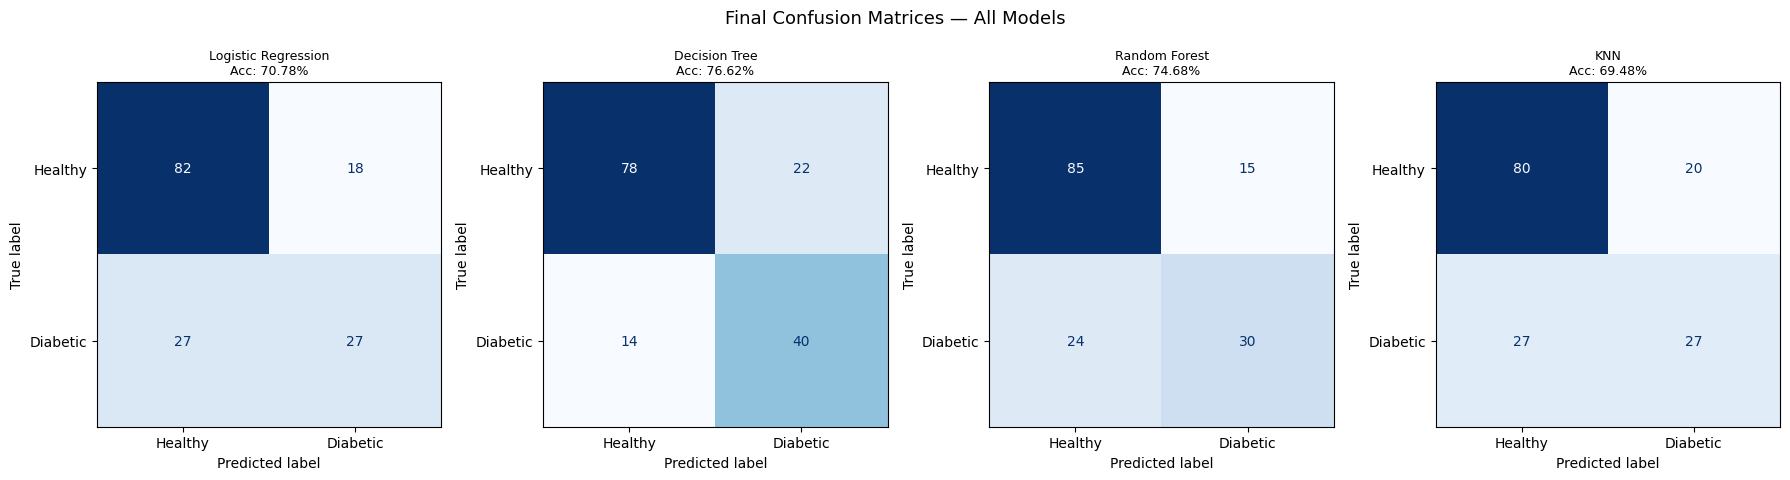


=== FINAL REPORT: Random Forest (Tuned) ===
              precision    recall  f1-score   support

     Healthy       0.78      0.85      0.81       100
    Diabetic       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



In [ ]:
# ■■ Final Evaluation Dashboard ■■
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42, stratify=y)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
Final_models = {
'Logistic Regression': Pipeline([('sc',StandardScaler()),('m',LogisticRegression(max_iter=1000))]),
'Decision Tree' : DecisionTreeClassifier(max_depth=5, random_state=42),
'Random Forest' : gs.best_estimator_, # Tuned version
'KNN' : Pipeline([('sc',StandardScaler()),('m',KNeighborsClassifier(n_neighbors=7))]),
}
final_results = []
for ax, (name, model) in zip(axes, Final_models.items()):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  cm = confusion_matrix(y_test, y_pred)
  ConfusionMatrixDisplay(cm, display_labels=['Healthy','Diabetic']).plot(
  ax=ax, cmap='Blues', colorbar=False)
  ax.set_title(f'{name}\nAcc: {acc:.2%}', fontsize=9)
  final_results.append({'Model':name, 'Test Accuracy':f'{acc:.2%}'})
plt.suptitle('Final Confusion Matrices — All Models', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
best_model = Final_models['Random Forest']
print('\n=== FINAL REPORT: Random Forest (Tuned) ===')
print(classification_report(y_test, best_model.predict(X_test),
target_names=['Healthy','Diabetic']))